# Agent class with methods to implement stubbornness

In [ ]:
import numpy as np

class Agent :
    '''
    Defines the basic methods for the agent.
    '''

    def __init__(self, parameters:dict):
        self.parameters = parameters
        # Determines the number of feedback options.
        assert(parameters["num_feedback_options"] is not None)
        self.num_feedback_options = parameters["num_feedback_options"]
        # Determines the exploration parameter for the UCB algorithm.
        assert(parameters["c"] is not None)
        self.c = parameters["c"]

        # Memory variables for the agent.
        self.prev_choice = None
        self.values = [0] * self.num_feedback_options # One value for each feedback option.
        self.counts = [0] * self.num_feedback_options # One count for each feedback option.

    def get_stubbornness_vector(self):
        '''
        Agent determines the stubbornness of each feedback option.
        '''
        feedback_option_values = [0] * self.num_feedback_options
        for i in range(self.num_feedback_options):
            feedback_option_values[i] = self.values[i] + self.get_ucb_value(i)

        return self.softmax(feedback_option_values)
        
    def get_ucb_value(self, feedback_option):
        if self.counts[feedback_option] > 0:
            # Get count of the feedback option. 
            N = self.counts[feedback_option] 
        else:
            # Initially, count starts at 1.
            N = 1
        # Get total count of all feedback options.
        t = sum(self.counts) + 1
        return self.c * np.sqrt(np.log(t) / N)

    def softmax(self, feedback_option_values):
        '''
        Agent determines the probability of choosing each feedback option.
        '''
        max_value = np.max(feedback_option_values)
        feedback_option_values = feedback_option_values - max_value 
        exp_values = np.exp(feedback_option_values)
        return exp_values / np.sum(exp_values)

    def update(self, reward):
        '''
        Agent updates the ucb of the previous choice.
        '''
        i = self.prev_choice
        # Update the count of the previous choice.
        self.counts[i] += 1
        N = self.counts[i]
        # Update the value of the previous choice (online average).
        self.values[i] += 1/N * (reward - self.values[i])

    def reset(self):
        '''
        Restarts the agent's data for a new simulation.
        '''
        self.prev_choice = None
        self.values = [0] * self.num_feedback_options
        self.counts = [0] * self.num_feedback_options


### Example

In [ ]:
parameters = {
    "num_feedback_options": 2,
    "c": 2.0,
}
num_rounds = 3
agent = Agent(parameters)

for r in range(num_rounds):
    print('='*60)
    print(f'Round {r+1}')
    print('='*60)
    print(f'Values: {agent.values}')
    stubbornness_vector = agent.get_stubbornness_vector()
    print(f'Stubbornness vector: {stubbornness_vector}')
    choice = np.random.choice(
        agent.num_feedback_options, 
        p=stubbornness_vector
    )
    print(f'Chosen feedback option: {choice}')
    # Assume choice 0 has a higher reward than choice 1.
    if choice == 0:
        reward = np.random.randint(0, 10)
    else:
        reward = np.random.randint(0, 5)
    print(f'Reward: {reward}')
    agent.prev_choice = choice
    agent.update(reward)

Round 1
Values: [0, 0]
Stubbornness vector: [0.5 0.5]
Chosen feedback option: 1
Reward: 4
Round 2
Values: [0, 4.0]
Stubbornness vector: [0.01798621 0.98201379]
Chosen feedback option: 1
Reward: 3
Round 3
Values: [0, 3.5]
Stubbornness vector: [0.0528495 0.9471505]
Chosen feedback option: 1
Reward: 2


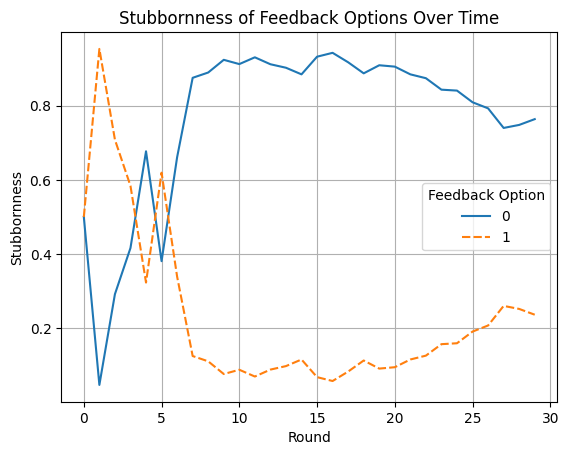

In [18]:
num_rounds = 30
agent = Agent(parameters)
stubbornness_list = []

for r in range(num_rounds):
    stubbornness_vector = agent.get_stubbornness_vector()
    stubbornness_list.append(stubbornness_vector)
    choice = np.random.choice(
        agent.num_feedback_options, 
        p=stubbornness_vector
    )
    # Assume choice 0 has a higher reward than choice 1.
    if choice == 0:
        reward = np.random.randint(0, 10)
    else:
        reward = np.random.randint(0, 8)
    agent.prev_choice = choice
    agent.update(reward)

stubbornness_array = np.array(stubbornness_list)

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=stubbornness_array)
plt.grid()
plt.xlabel('Round')
plt.ylabel('Stubbornness')
plt.title('Stubbornness of Feedback Options Over Time')
plt.legend(title='Feedback Option')
plt.show()